In [1]:
import os

os.chdir("../")

import hydra
import matplotlib.pyplot as plt

In [2]:
import os

# ここを自分の環境に合わせて変更してください
os.environ["PROJECT_ROOT"] = "/home/yuhix/school/Lab/kandinsky-calibration"
os.environ["DATA_TRAINVAL_ROOT"] = "/home/yuhix/school/Lab/kandisky-data/coco/trainval"   # coco-prepare.py の trainval_dir
os.environ["DATA_TEST_ROOT"]     = "/home/yuhix/school/Lab/kandisky-data/coco/test"       # coco-prepare.py の test_dir


In [3]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize(version_base="1.3", config_path="../configs/")
cfg = hydra.compose(config_name="train.yaml", overrides=["data.trainval_split=pilot"])
dm = hydra.utils.instantiate(cfg.data)


# Train images (with augmentation)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
300


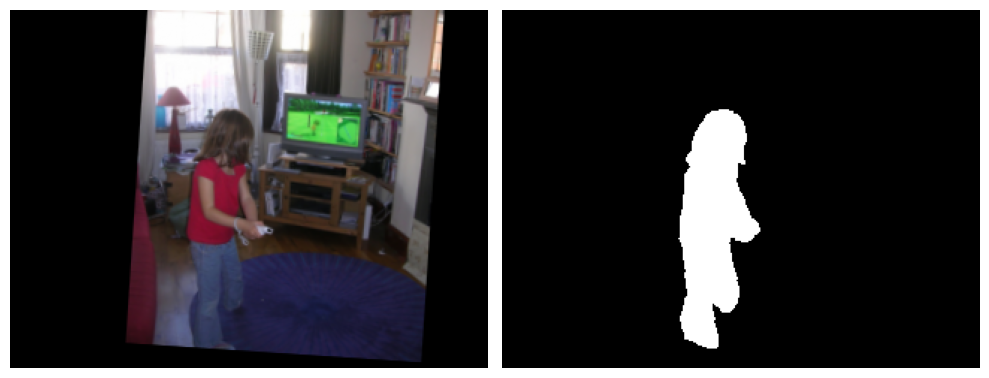

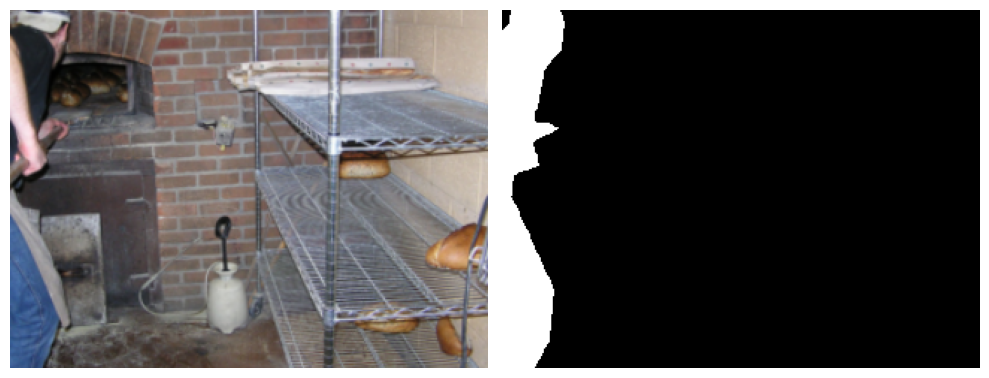

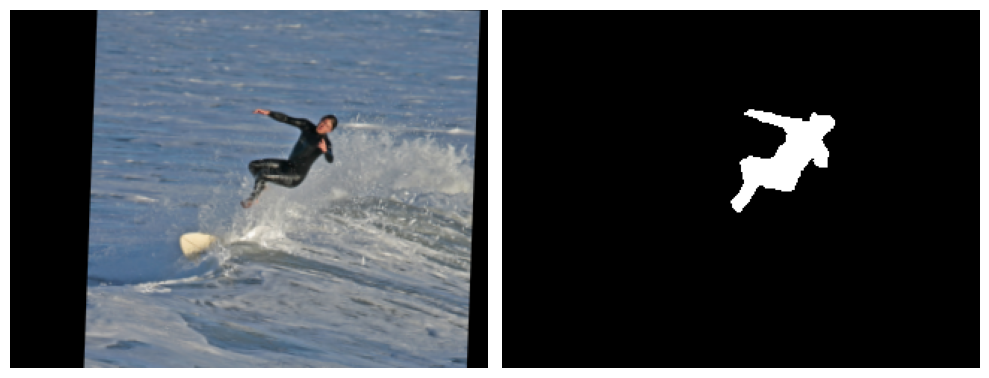

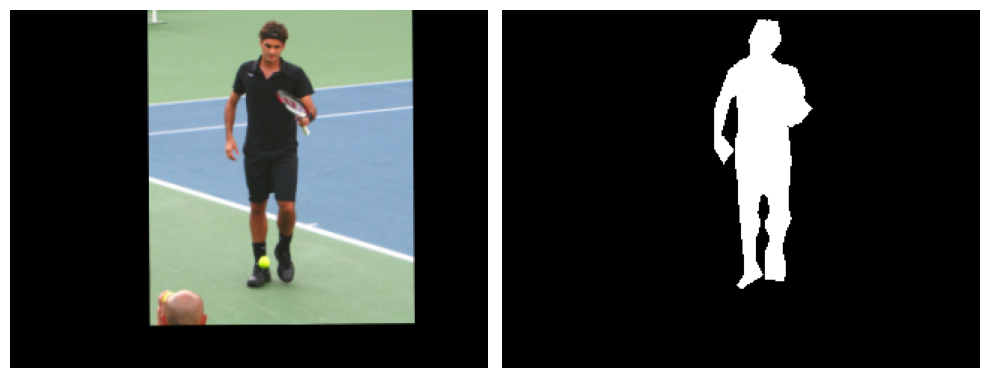

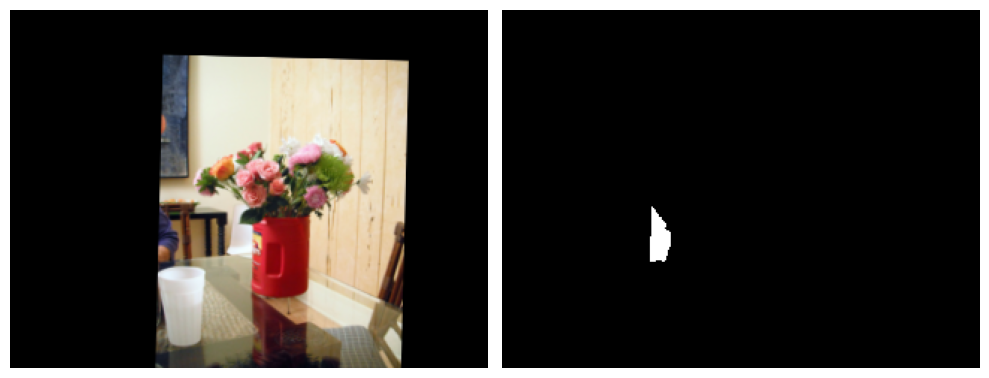

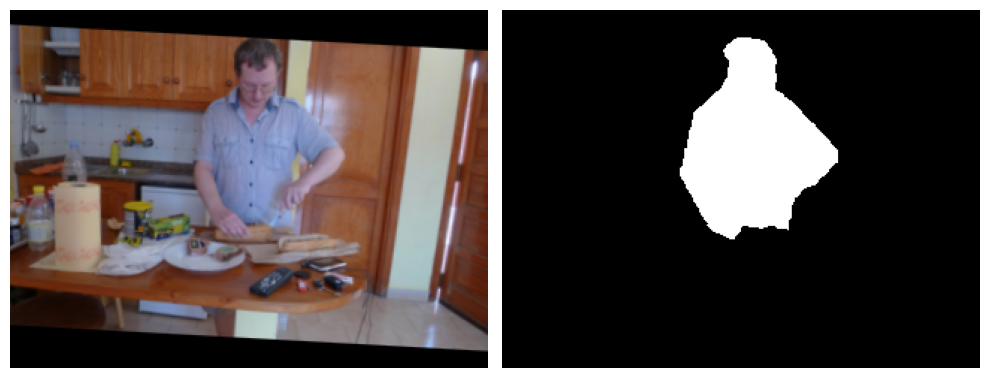

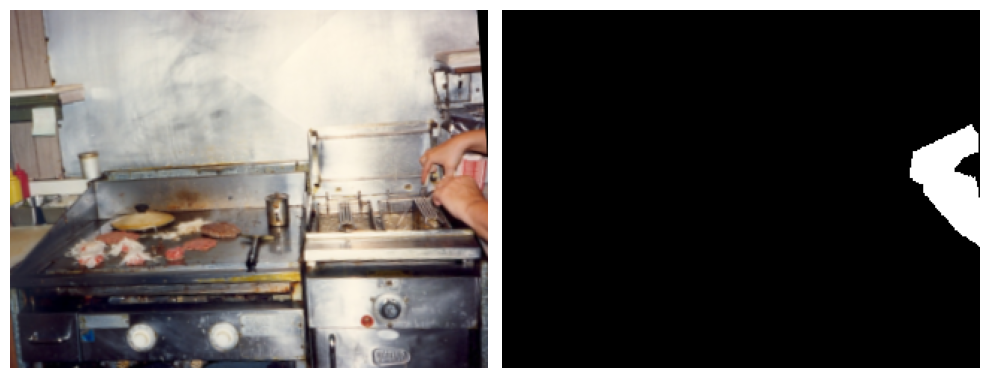

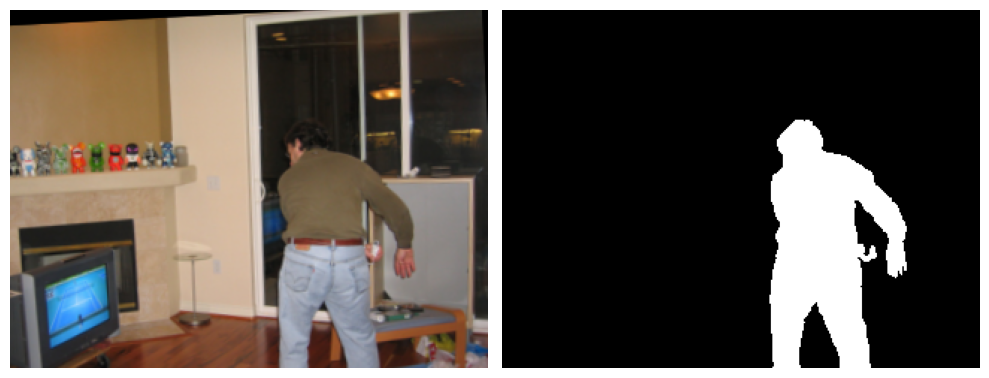

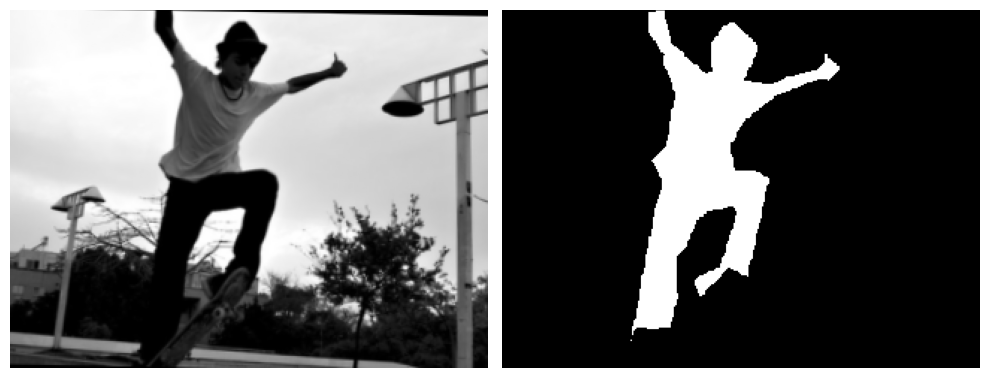

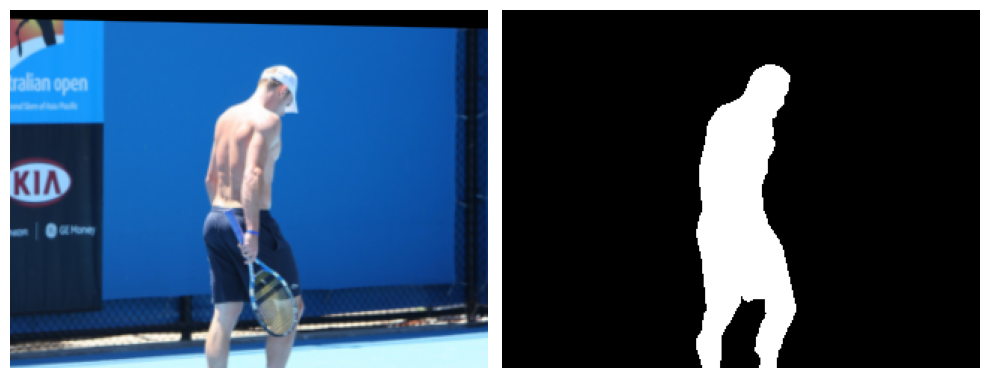

In [4]:
dm.setup(stage="fit")
train_ds = dm._data_train

print(len(train_ds))

for i in range(10):
    item = train_ds[i]
    img = item["image"].permute(1, 2, 0)
    mask = item["target_segmentation"][1]
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img)
    ax[1].imshow(mask, cmap="gray")
    ax[0].axis("off")
    ax[1].axis("off")

    fig.tight_layout()

    plt.show()

# Validation images (no augmentation)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
50


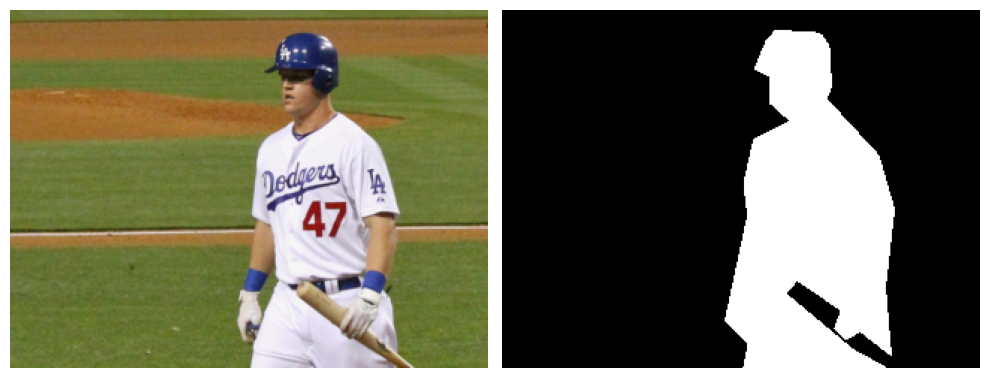

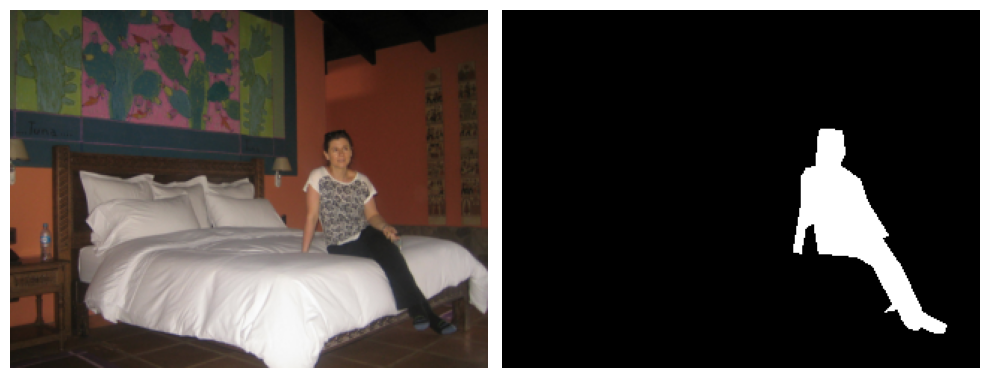

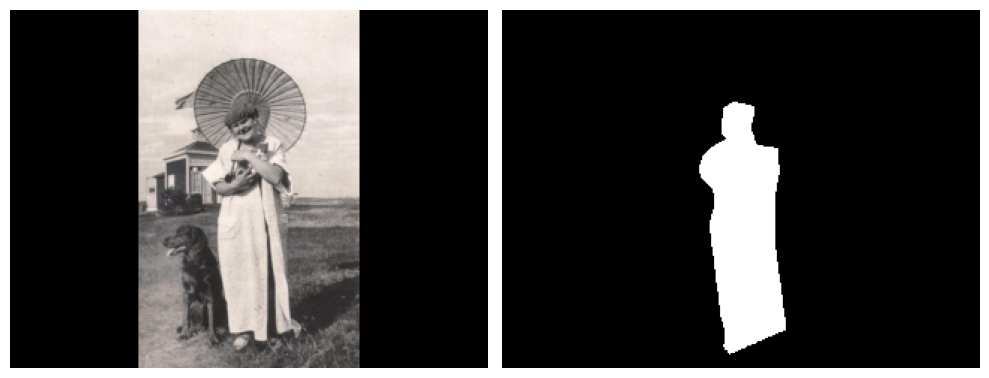

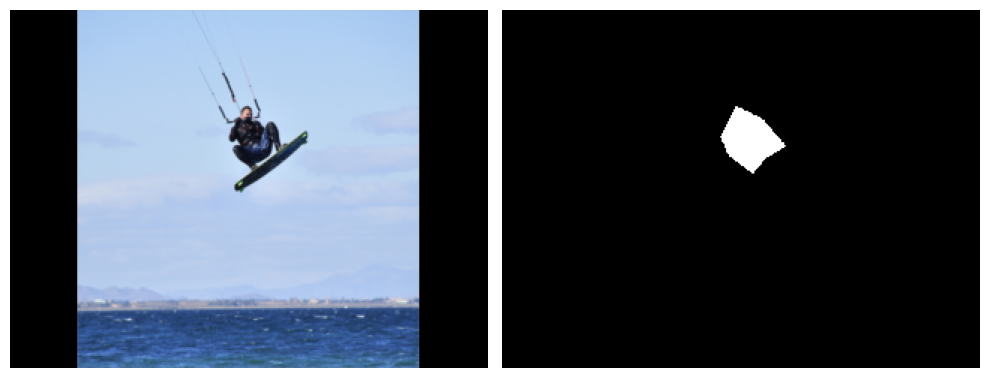

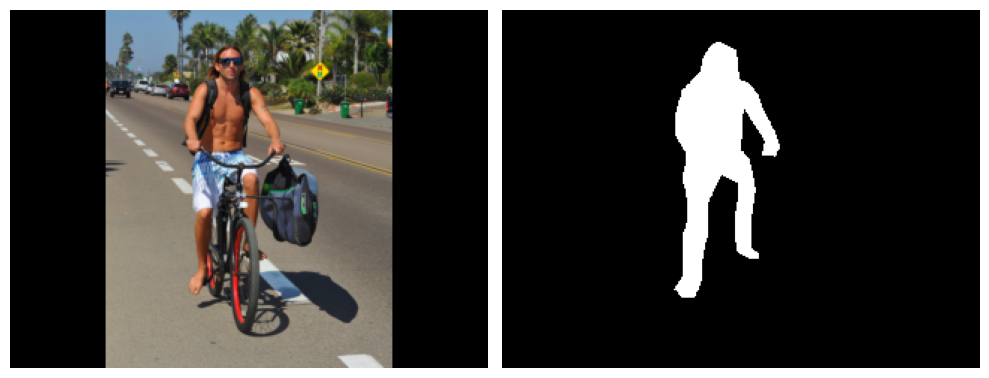

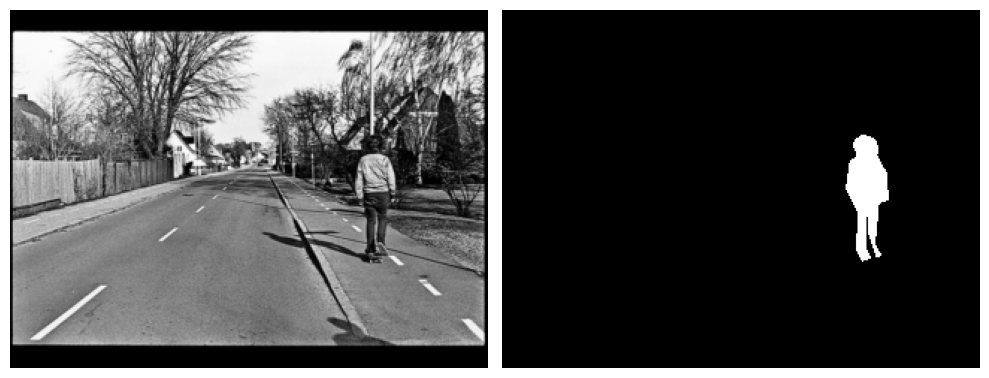

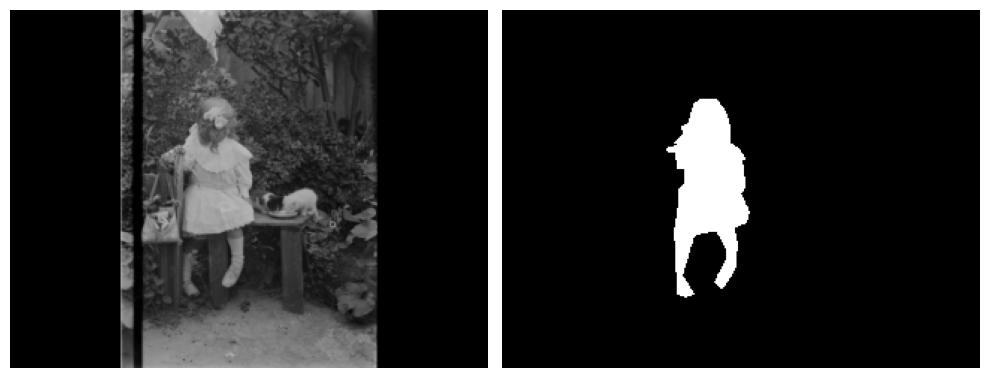

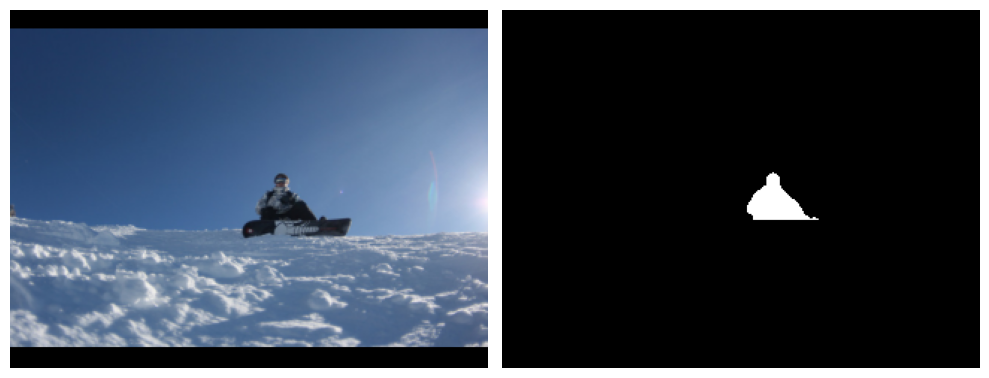

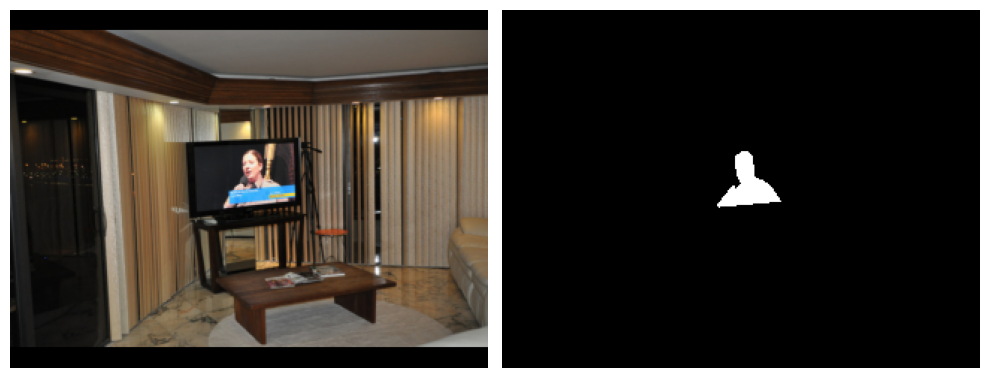

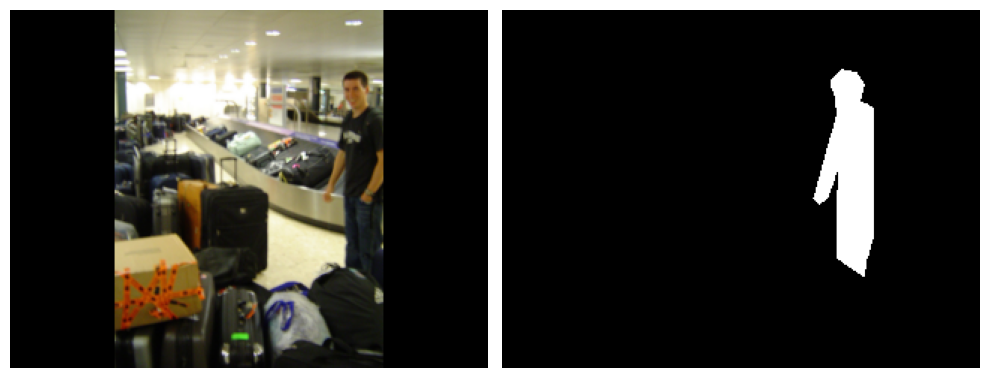

In [5]:
dm.setup(stage="fit")
val_ds = dm._data_val

print(len(val_ds))

for i in range(10):
    item = val_ds[i]
    img = item["image"].permute(1, 2, 0)
    mask = item["target_segmentation"][1]
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img)
    ax[1].imshow(mask, cmap="gray")
    ax[0].axis("off")
    ax[1].axis("off")

    fig.tight_layout()

    plt.show()